# Beta Bank Churn, by Deborah Thomas

## <div style="color: red; border: 2px solid yellow; display: inline-block;">Introduction</div>

- I will develop a model, that will analyze bank customers' data, to predict whether a customer will leave Beta Bank soon.
- I will use evaluation metrics to test the model.

## <div style="color: red; border: 2px solid yellow; display: inline-block;">Import Libraries</div>

In [495]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler

import plotly.express as px

## <div style="color: red; border: 2px solid yellow; display: inline-block;">Download the Data</div>

In [497]:
try:
    churn = pd.read_csv('/datasets/Churn.csv')  # Attempt to read from the server path
except FileNotFoundError:
    churn = pd.read_csv('../datasets/Churn.csv')  # Fallback to the local path


display(churn.head(20))

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8.0,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7.0,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4.0,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4.0,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2.0,134603.88,1,1,1,71725.73,0


## <div style="color: red; border: 2px solid yellow; display: inline-block;">Clean the Data</div>

 ### <span style="color:red">Rename columns to shorter names</span>

In [500]:
churn.rename(columns={'RowNumber': 'Row#', 'CustomerId': 'CustID', 'Surname': 'Name', 'CreditScore': 'CredScore', 'Geography': 'Geo', 'NumOfProducts': 'NumProds', 'IsActiveMember': 'Active', 'EstimatedSalary': 'Salary', 'Exited': 'Churned'}, inplace=True)

In [501]:
display(churn.head(3))

,Row#,CustID,Name,CredScore,Geo,Gender,Age,Tenure,Balance,NumProds,HasCrCard,Active,Salary,Churned
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1


 ### <span style="color:red">Active / Churned</span>

In [503]:
print(churn[['Active', 'Churned']].head(5))

   Active  Churned
0       1        1
1       1        0
2       0        1
3       0        0
4       1        0


#### This is interesting. There are some customers who have already churned, but are still active.

### <span style="color:red">Name</span>

In [506]:
# Filter names that start with "Ch'ien" or contain a single apostrophe, due to an error that I had fitting the model.
filtered_names = churn[churn['Name'].str.startswith('Chi\'en') | churn['Name'].str.contains("'")]
display(filtered_names.head(15))

,Row#,CustID,Name,CredScore,Geo,Gender,Age,Tenure,Balance,NumProds,HasCrCard,Active,Salary,Churned
52,53,15683553,O'Brien,788,France,Female,33,5.0,0.00,2,0,0,116978.19,0
58,59,15623944,T'ien,511,Spain,Female,66,4.0,0.00,1,1,0,1643.11,1
109,110,15744689,T'ang,479,Germany,Male,35,9.0,92833.89,1,1,0,99449.86,1
183,184,15810845,T'ang,636,France,Male,42,2.0,0.00,2,1,1,55470.78,0
186,187,15771977,T'ao,730,France,Female,39,1.0,99010.67,1,1,0,194945.80,0
226,227,15774393,Ch'ien,694,France,Female,30,9.0,0.00,2,1,1,26960.31,0
228,229,15637753,O'Sullivan,751,Germany,Male,50,2.0,96888.39,1,1,0,77206.25,1
265,266,15813163,Ch'iu,531,Spain,Female,36,9.0,99240.51,1,1,0,123137.01,0
279,280,15782210,K'ung,714,France,Male,46,1.0,0.00,1,1,0,152167.79,1
283,284,15699389,Ch'ien,807,France,Male,42,7.0,118274.71,1,1,1,25885.72,0


- Just looking to see if there are names with single apostrophes because I had an error fitting the data.
- I think it's best to drop the Name column when I split the data, later on, as this column will not give meaningful information when predicting target data. 

In [508]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Row#       10000 non-null  int64  
 1   CustID     10000 non-null  int64  
 2   Name       10000 non-null  object 
 3   CredScore  10000 non-null  int64  
 4   Geo        10000 non-null  object 
 5   Gender     10000 non-null  object 
 6   Age        10000 non-null  int64  
 7   Tenure     9091 non-null   float64
 8   Balance    10000 non-null  float64
 9   NumProds   10000 non-null  int64  
 10  HasCrCard  10000 non-null  int64  
 11  Active     10000 non-null  int64  
 12  Salary     10000 non-null  float64
 13  Churned    10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


 ### <span style="color:red">Look for missing data:</span>

#### 'Tenure' has some missing data. 909 rows have invalid data.

In [511]:
# Find and display the rows where 'Tenure' is missing
missing_tenure_rows = churn[churn['Tenure'].isna()]

print("\nRows with missing 'tenure' values:")
display(missing_tenure_rows.head(9))


Rows with missing 'tenure' values:


,Row#,CustID,Name,CredScore,Geo,Gender,Age,Tenure,Balance,NumProds,HasCrCard,Active,Salary,Churned
30,31,15589475,Azikiwe,591,Spain,Female,39,NaN,0.00,3,1,0,140469.38,1
48,49,15766205,Yin,550,Germany,Male,38,NaN,103391.38,1,0,1,90878.13,0
51,52,15768193,Trevisani,585,Germany,Male,36,NaN,146050.97,2,0,0,86424.57,0
53,54,15702298,Parkhill,655,Germany,Male,41,NaN,125561.97,1,0,0,164040.94,1
60,61,15651280,Hunter,742,Germany,Male,35,NaN,136857.00,1,0,0,84509.57,0
82,83,15641732,Mills,543,France,Female,36,NaN,0.00,2,0,0,26019.59,0
85,86,15805254,Ndukaku,652,Spain,Female,75,NaN,0.00,2,1,1,114675.75,0
94,95,15676966,Capon,730,Spain,Male,42,NaN,0.00,2,0,1,85982.47,0
99,100,15633059,Fanucci,413,France,Male,34,NaN,0.00,2,0,0,6534.18,0


In [512]:
# Fill NaN values
churn['Tenure'] = churn['Tenure'].fillna(churn['Tenure'].median())

#### I am not going to drop these rows, that have NaN 'Tenure', but I will fill them with the median value of the column, as leaving in the NaN will create an error when fitting the model, later on.

In [514]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Row#       10000 non-null  int64  
 1   CustID     10000 non-null  int64  
 2   Name       10000 non-null  object 
 3   CredScore  10000 non-null  int64  
 4   Geo        10000 non-null  object 
 5   Gender     10000 non-null  object 
 6   Age        10000 non-null  int64  
 7   Tenure     10000 non-null  float64
 8   Balance    10000 non-null  float64
 9   NumProds   10000 non-null  int64  
 10  HasCrCard  10000 non-null  int64  
 11  Active     10000 non-null  int64  
 12  Salary     10000 non-null  float64
 13  Churned    10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


 ### <span style="color:red">Data types:</span>

#### Changing Tenure to int, because none of the values will change if whole numbers are used.

In [517]:
churn['Tenure'] = churn['Tenure'].astype(int)

In [518]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Row#       10000 non-null  int64  
 1   CustID     10000 non-null  int64  
 2   Name       10000 non-null  object 
 3   CredScore  10000 non-null  int64  
 4   Geo        10000 non-null  object 
 5   Gender     10000 non-null  object 
 6   Age        10000 non-null  int64  
 7   Tenure     10000 non-null  int64  
 8   Balance    10000 non-null  float64
 9   NumProds   10000 non-null  int64  
 10  HasCrCard  10000 non-null  int64  
 11  Active     10000 non-null  int64  
 12  Salary     10000 non-null  float64
 13  Churned    10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


 ### <span style="color:red">Encoding</span>

- <span style="color:red">Encode Geography column in to 2 new columns(regions), and dropping first column(France):</span>

In [521]:
churn['Geo'].value_counts()

Geo
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [522]:
# Apply One-Hot Encoding to Geo column.
churn_ohe = pd.get_dummies(churn, columns=['Geo'], drop_first=True)

print("\nOne-Hot Encoded DataFrame:")
display(churn_ohe.head(3))


One-Hot Encoded DataFrame:


,Row#,CustID,Name,CredScore,Gender,Age,Tenure,Balance,NumProds,HasCrCard,Active,Salary,Churned,Geo_Germany,Geo_Spain
0,1,15634602,Hargrave,619,Female,42,2,0.00,1,1,1,101348.88,1,False,False
1,2,15647311,Hill,608,Female,41,1,83807.86,1,0,1,112542.58,0,False,True
2,3,15619304,Onio,502,Female,42,8,159660.80,3,1,0,113931.57,1,False,False


- <span style="color:red">Encode Gender in to 2 new columns</span>

In [524]:
# Apply One-Hot Encoding to Gender column.
churn_ohe = pd.get_dummies(churn_ohe, columns=['Gender'], drop_first=False)

In [525]:
print("\nOne-Hot Encoded DataFrame:")
display(churn_ohe.head(3))


One-Hot Encoded DataFrame:


,Row#,CustID,Name,CredScore,Age,Tenure,Balance,NumProds,HasCrCard,Active,Salary,Churned,Geo_Germany,Geo_Spain,Gender_Female,Gender_Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,False,False,True,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,False,True,True,False
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,False,False,True,False


- <span style="color:red">Encode Number of Products in to 4 new columns:</span>

In [527]:
# Apply One-Hot Encoding to Gender column.
churn_ohe = pd.get_dummies(churn_ohe, columns=['NumProds'], drop_first=False)

print("\nOne-Hot Encoded DataFrame:")
display(churn_ohe.head(3))


One-Hot Encoded DataFrame:


,Row#,CustID,Name,CredScore,Age,Tenure,Balance,HasCrCard,Active,Salary,Churned,Geo_Germany,Geo_Spain,Gender_Female,Gender_Male,NumProds_1,NumProds_2,NumProds_3,NumProds_4
0,1,15634602,Hargrave,619,42,2,0.00,1,1,101348.88,1,False,False,True,False,True,False,False,False
1,2,15647311,Hill,608,41,1,83807.86,0,1,112542.58,0,False,True,True,False,True,False,False,False
2,3,15619304,Onio,502,42,8,159660.80,1,0,113931.57,1,False,False,True,False,False,False,True,False


- <span style="color:red">Encode HasCrCard column in to 2 new columns:</span>

In [529]:
# Apply One-Hot Encoding to Gender column.
churn_ohe = pd.get_dummies(churn_ohe, columns=['HasCrCard'], drop_first=False)

print("\nOne-Hot Encoded DataFrame:")
display(churn_ohe.head(3))


One-Hot Encoded DataFrame:


,Row#,CustID,Name,CredScore,Age,Tenure,Balance,Active,Salary,Churned,Geo_Germany,Geo_Spain,Gender_Female,Gender_Male,NumProds_1,NumProds_2,NumProds_3,NumProds_4,HasCrCard_0,HasCrCard_1
0,1,15634602,Hargrave,619,42,2,0.00,1,101348.88,1,False,False,True,False,True,False,False,False,False,True
1,2,15647311,Hill,608,41,1,83807.86,1,112542.58,0,False,True,True,False,True,False,False,False,True,False
2,3,15619304,Onio,502,42,8,159660.80,0,113931.57,1,False,False,True,False,False,False,True,False,False,True


In [530]:
churn_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row#           10000 non-null  int64  
 1   CustID         10000 non-null  int64  
 2   Name           10000 non-null  object 
 3   CredScore      10000 non-null  int64  
 4   Age            10000 non-null  int64  
 5   Tenure         10000 non-null  int64  
 6   Balance        10000 non-null  float64
 7   Active         10000 non-null  int64  
 8   Salary         10000 non-null  float64
 9   Churned        10000 non-null  int64  
 10  Geo_Germany    10000 non-null  bool   
 11  Geo_Spain      10000 non-null  bool   
 12  Gender_Female  10000 non-null  bool   
 13  Gender_Male    10000 non-null  bool   
 14  NumProds_1     10000 non-null  bool   
 15  NumProds_2     10000 non-null  bool   
 16  NumProds_3     10000 non-null  bool   
 17  NumProds_4     10000 non-null  bool   
 18  HasCrCa

#### The new columns are of type uint8, which takes up the least amount of disk space. This is good.

### Data is clean now

## <div style="color: red; border: 2px solid yellow; display: inline-block;">Explore the Data</div>

### <span style="color:red">Credit Score</span>

In [535]:
churn['CredScore'].value_counts()

CredScore
850    233
678     63
655     54
705     53
667     53
      ... 
404      1
351      1
365      1
417      1
419      1
Name: count, Length: 460, dtype: int64

### What is the comparison of credit score to churned customers?

In [537]:
churn['CredScore'].min()

350

In [538]:
churn['CredScore'].max()

850

In [539]:
# break the 'CredScore' column into different levels,  based on the distribution of credit scores.
# Define custom bins and labels
bins = [349, 425, 500, 575, 650, 725, float('inf')]
labels = ['very poor', 'poor', 'okay', 'good', 'very good', 'excellent']

In [540]:
# Bin the 'CredScore' into defined levels and assign labels
churn['CredScoreLevel'] = pd.cut(churn['CredScore'], bins=bins, labels=labels)

In [541]:
# Display the updated DataFrame
print(churn[['CredScore', 'CredScoreLevel']].head(15))

    CredScore CredScoreLevel
0         619           good
1         608           good
2         502           okay
3         699      very good
4         850      excellent
5         645           good
6         822      excellent
7         376      very poor
8         501           okay
9         684      very good
10        528           okay
11        497           poor
12        476           poor
13        549           okay
14        635           good


In [542]:
# Group by 'CredScoreLevel' and 'Churned', then count occurrences
credscore_churn_counts = churn.groupby(['CredScoreLevel', 'Churned'], observed=False).size().reset_index(name='Count')

In [543]:
churn['CredScoreLevel'].value_counts()

CredScoreLevel
very good    2793
good         2695
excellent    2270
okay         1599
poor          573
very poor      70
Name: count, dtype: int64

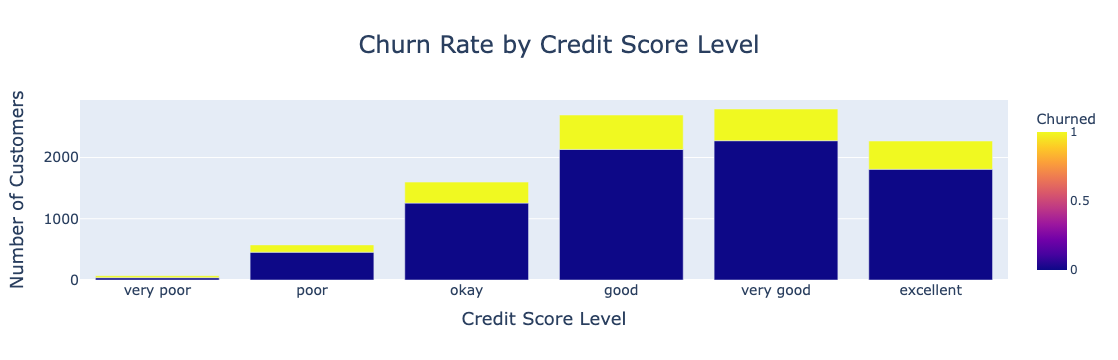

In [544]:
fig = px.bar(
    credscore_churn_counts,
    x='CredScoreLevel',
    y='Count',
    color='Churned',
    barmode='group',
    title='Churn Rate by Credit Score Level',
    labels={'CredScoreLevel': 'Credit Score Level', 'Count': 'Number of Customers'}
)

# Customize the title and axis labels
fig.update_layout(
    title={
        'text': "Churn Rate by Credit Score Level",
        'y': 0.9,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}  # Adjust the font size of the title
    },
    xaxis_title={
        'text': 'Credit Score Level',
        'font': {'size': 18}  # Adjust the x-axis title font size
    },
    yaxis_title={
        'text': 'Number of Customers',
        'font': {'size': 18}  # Adjust the y-axis title font size
    }
)

# Adjust the font size of the tick labels
fig.update_xaxes(tickfont={'size': 14})
fig.update_yaxes(tickfont={'size': 14})

fig.show()

### Credit Score breakdown:
The credit scores, on this dataset, go from 350-850.

- very poor ... 349-424
- poor      ... 425-499
- okay      ... 500-574
- good      ... 575-649
- very good ... 650-724
- excellent ... 725-850


In [546]:
print("Churn rate for customers with very poor credit:")
33 / (33 + 37) * 100

Churn rate for customers with very poor credit:


47.14285714285714

In [547]:
print("Churn rate for customers with poor credit:")
119 / (119 + 454) * 100

Churn rate for customers with poor credit:


20.76788830715532

In [548]:
print("Churn rate for customers with okay credit:")
343/ (343 + 1256) * 100

Churn rate for customers with okay credit:


21.450906816760476

In [549]:
print("Churn rate for customers with good credit:")
562 / (562 + 2133) * 100

Churn rate for customers with good credit:


20.853432282003713

In [550]:
print("Churn rate for customers with very good credit:")
518 / (518 + 2275) * 100

Churn rate for customers with very good credit:


18.546365914786968

In [551]:
print("Churn rate for customers with excellent credit:")
462 / (462 + 1808) * 100

Churn rate for customers with excellent credit:


20.352422907488986

- The majority of customers have very good credit. 
- All levels, except 'very poor' credit, have a churn rate approximately between 18\% - 21\%.
- Customers with 'very poor' credit have a much higher churn rate than other credit levels, at 47\%.

### <span style="color:red">Geography</span>

In [554]:
churn.Geo.value_counts()

Geo
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

#### The dataset only includes data from the regions of France, Germany, and Spain.

### What is the churn rate for customers from these 3 regions?

In [557]:
# Group by 'Geo' and 'Churned', then count occurrences
geo_churn_counts = churn.groupby(['Geo', 'Churned']).size().reset_index(name='Count')

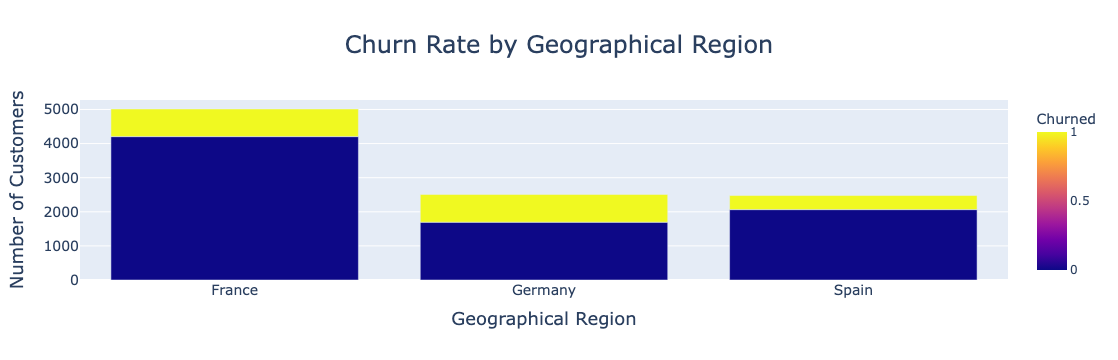

In [558]:
fig = px.bar(
    geo_churn_counts,
    x='Geo',
    y='Count',
    color='Churned',
    barmode='group',
    title='Churn Rate by Geographical Region',
    labels={'Geo': 'Geographical Region', 'Count': 'Number of Customers'}
)

# Customize the title and axis labels
fig.update_layout(
    title={
        'text': "Churn Rate by Geographical Region",
        'y': 0.9,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}  # Adjust the font size of the title
    },
    xaxis_title={
        'text': 'Geographical Region',
        'font': {'size': 18}  # Adjust the x-axis title font size
    },
    yaxis_title={
        'text': 'Number of Customers',
        'font': {'size': 18}  # Adjust the y-axis title font size
    }
)
# Adjust the font size of the tick labels
fig.update_xaxes(tickfont={'size': 14})
fig.update_yaxes(tickfont={'size': 14})


fig.show()


In [559]:
print("Churn rate for customers from France:")
810 / 4204

Churn rate for customers from France:


0.19267364414843008

In [560]:
print("Churn rate for customers from Germany:")
814 / 1695

Churn rate for customers from Germany:


0.48023598820059

In [561]:
print("Churn rate for customers from Spain:")
413 / 2064

Churn rate for customers from Spain:


0.2000968992248062

- The churn rate for customers from France and Spain are about the same, approximately 20\%
- The churn rate for customers from Germany is more than double that of France or Spain, at 48\%.

### <span style="color:red">Gender</span>

In [564]:
churn.Gender.value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

#### Most customers are male.

### What is the churn rate of customers, by gender?

In [567]:
# Group by 'Churned' and 'Gender', then count occurrences
gender_churned_counts = churn.groupby(['Churned', 'Gender']).size().reset_index(name='Count')

# Filter for rows where 'Churned' is True
true_gender_churned_counts = gender_churned_counts[gender_churned_counts['Churned'] == True]

print(true_gender_churned_counts)

   Churned  Gender  Count
2        1  Female   1139
3        1    Male    898


In [568]:
print("Churn rate for females:")

Churn rate for females:


In [569]:
1139 / 4543 * 100

25.071538630860662

In [570]:
print("Churn rate for males:")

Churn rate for males:


In [571]:
898 /  5457 * 100

16.455928165658786

- The churn rate for females is 25\%.
- The churn rate for males is 16\%.

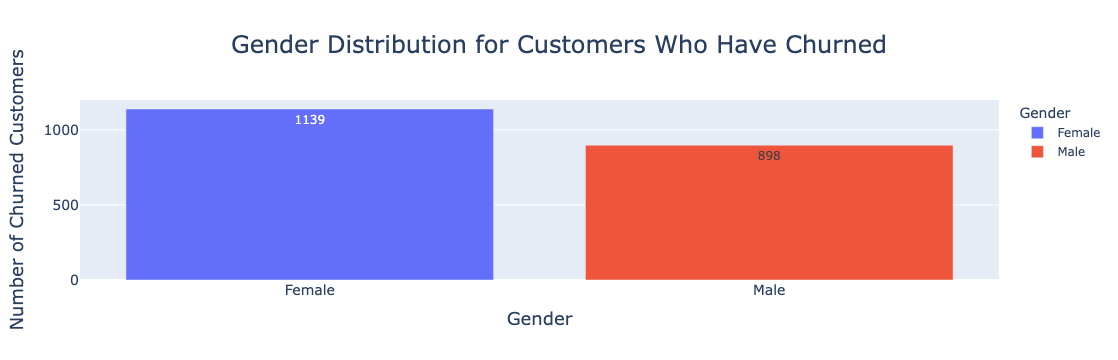

In [573]:
# Create bar graph using Plotly Express
fig = px.bar(
    true_gender_churned_counts,
    x='Gender',
    y='Count',
    title='Gender Distribution for Customers Who Have Churned',
    labels={'Count': 'Number of Churned Customers', 'Gender': 'Gender'},
    color='Gender',
    text='Count'
)
# Center the title and make it bigger
fig.update_layout(
    title={
        'text': "Gender Distribution for Customers Who Have Churned",
        'y':0.9,  # Adjust the vertical position of the title
        'x':0.5,  # Center the title
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}  # Adjust the font size of the title
    },
    xaxis_title={
        'text': 'Gender',
        'font': {'size': 18}  # Adjust the x-axis title font size
    },
    yaxis_title={
        'text': 'Number of Churned Customers',
        'font': {'size': 18}  # Adjust the y-axis title font size
    }
)
# Make the tick labels on both axes bigger
fig.update_xaxes(tickfont={'size': 14})
fig.update_yaxes(tickfont={'size': 14})

fig.show()

#### More female customers churn than male customers.

### <span style="color:red">Age</span>

In [576]:
churn['Age'].min()

18

In [577]:
churn['Age'].max()

92

In [578]:
# Group by 'Age' and 'Churned', then count occurrences
age_churn_counts = churn.groupby(['Age', 'Churned']).size().reset_index(name='Count')

In [579]:
# Map the 0 and 1 values to 'False' and 'True'
age_churn_counts['Churned'] = age_churn_counts['Churned'].map({0: 'False', 1: 'True'})

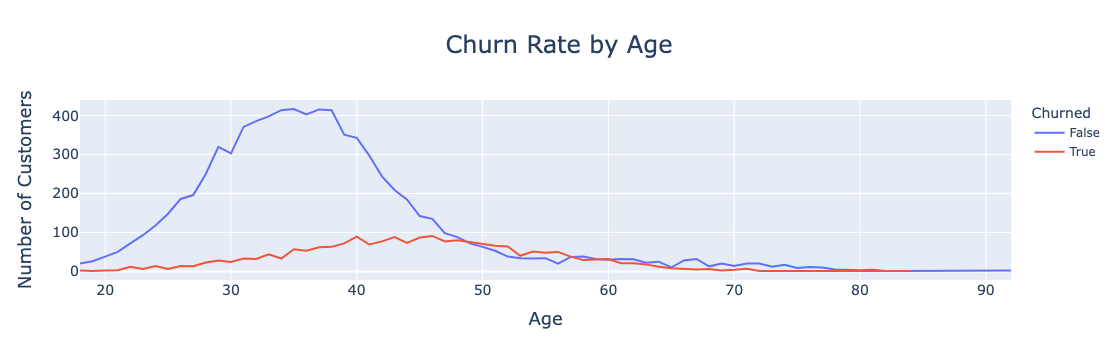

In [580]:
fig = px.line(
    age_churn_counts,
    x='Age',
    y='Count',
    color='Churned',
    title='Churn Rate by Age',
    labels={'Age': 'Age', 'Count': 'Number of Customers'}
)

# Customize the title and axis labels
fig.update_layout(
    title={
        'text': "Churn Rate by Age",
        'y': 0.9,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}  # Adjust the font size of the title
    },
    xaxis_title={
        'text': 'Age',
        'font': {'size': 18}  # Adjust the x-axis title font size
    },
    yaxis_title={
        'text': 'Number of Customers',
        'font': {'size': 18}  # Adjust the y-axis title font size
    }
)

# Adjust the font size of the tick labels
fig.update_xaxes(tickfont={'size': 14})
fig.update_yaxes(tickfont={'size': 14})


fig.show()


- Ages 23-48 have an extremely low churn rate than other ages, with the lowest churn ages being 35-37. 

### <span style="color:red">Tenure</span>

In [583]:
churn['Tenure'].value_counts()

Tenure
5     1836
1      952
2      950
8      933
3      928
7      925
4      885
9      882
6      881
10     446
0      382
Name: count, dtype: int64

In [584]:
# Group by 'Age' and 'Churned', then count occurrences
tenure_churn_counts = churn.groupby(['Tenure', 'Churned']).size().reset_index(name='Count')

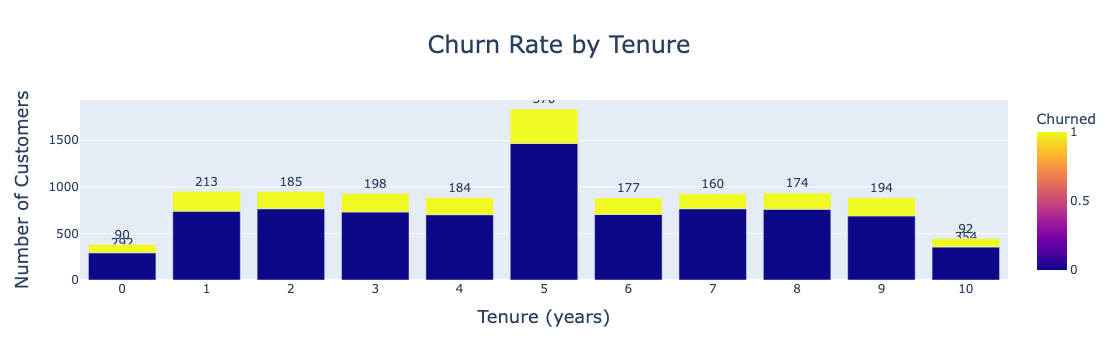

In [585]:
fig = px.bar(
    tenure_churn_counts,
    x='Tenure',
    y='Count',
    color='Churned',
    barmode='group',
    title='Churn Rate by Tenure',
    labels={'Tenure': 'Tenure (years)', 'Count': 'Number of Customers', 'Churned': 'Churned'},
    text='Count'
)

# Customize the title and axis labels
fig.update_layout(
    title={
        'text': "Churn Rate by Tenure",
        'y': 0.9,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}  # Adjust the font size of the title
    },
    xaxis_title={
        'text': 'Tenure (years)',
        'font': {'size': 18}  # Adjust the x-axis title font size
    },
    yaxis_title={
        'text': 'Number of Customers',
        'font': {'size': 18}  # Adjust the y-axis title font size
    }
)
# Adjust the text position for better readability
fig.update_traces(texttemplate='%{text}', textposition='outside')

# Set the x-axis ticks to display every tenure value
tenure_range = list(range(int(tenure_churn_counts['Tenure'].min()), int(tenure_churn_counts['Tenure'].max()) + 1))
fig.update_xaxes(tickvals=tenure_range)

fig.show()

#### There is a higher percentage of customers who have been tenured for 5 years.

### What are the percentage rates of churned customers, by Tenure ?

In [588]:
# Group by 'Tenure' and 'Churned', then count occurrences
tenure_churn_counts = churn.groupby(['Tenure', 'Churned']).size().reset_index(name='Count')

# Pivot the data to get counts for each 'Tenure' and 'Churned' status
pivot_df = tenure_churn_counts.pivot(index='Tenure', columns='Churned', values='Count').fillna(0)

In [589]:
# Rename columns for clarity
pivot_df.columns = ['Not_Churned', 'Churned']

# Calculate total customers per 'Tenure'
pivot_df['Total'] = pivot_df.sum(axis=1)

In [590]:
# Calculate the churn rate percentage
pivot_df['Churn_Rate (%)'] = (pivot_df['Churned'] / pivot_df['Total']) * 100

# Reset index for printing
pivot_df = pivot_df.reset_index()

In [591]:
# Print the result
print(pivot_df[['Tenure', 'Churn_Rate (%)']])

    Tenure  Churn_Rate (%)
0        0       23.560209
1        1       22.373950
2        2       19.473684
3        3       21.336207
4        4       20.790960
5        5       20.152505
6        6       20.090806
7        7       17.297297
8        8       18.649518
9        9       21.995465
10      10       20.627803


- The churn rate, by Tenure, ranges from 17.2\% - 23.5\%.  
- The lowest churn rate is for those customers with a Tenure of 7 and 8 years. 
- The highest churn rate is for those customers with a Tenure of 1 year or less.

### <span style="color:red">Bank Balance</span>

In [594]:
churn['Balance'].min()

0.0

In [595]:
churn['Balance'].max()

250898.09

In [596]:
churn['Balance'].mean()

76485.889288

#### The average bank balance is \$76,485.

In [598]:
# Create a copy of the DataFrame for visualization purposes
churn_viz = churn.copy()

In [599]:
# Map the 0 and 1 values to 'False' and 'True' in the copy
churn_viz['Churned'] = churn_viz['Churned'].map({0: 'False', 1: 'True'})

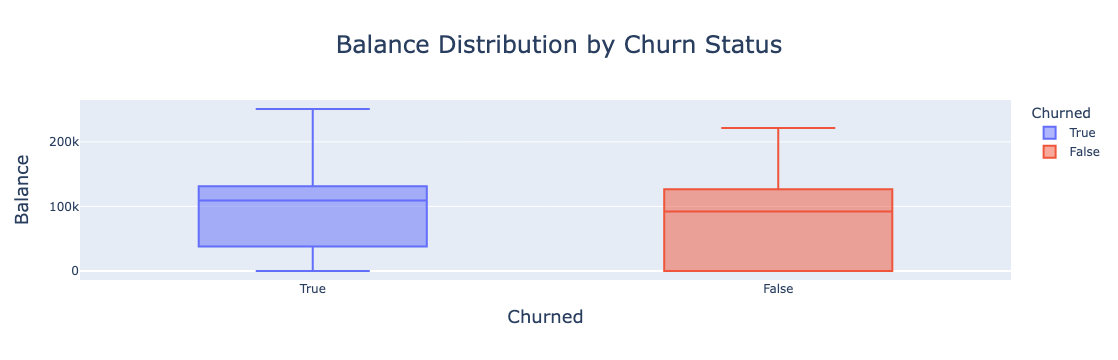

In [600]:
fig = px.box(churn_viz, x='Churned', y='Balance', color='Churned',
             title='Balance Distribution by Churn Status',
             labels={'Churned': 'Churned', 'Balance': 'Balance'})

# Customize the title and axis labels
fig.update_layout(
    title={
        'text': "Balance Distribution by Churn Status",
        'y': 0.9,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}  # Adjust the font size of the title
    },
    xaxis_title={
        'text': 'Churned',
        'font': {'size': 18}  # Adjust the x-axis title font size
    },
    yaxis_title={
        'text': 'Balance',
        'font': {'size': 18}  # Adjust the y-axis title font size
    }
)

fig.show()

#### The median churn rate, based on bank balance, is \$109,349

### <span style="color:red">Number of Products</span>

In [603]:
display(churn.head(3))

,Row#,CustID,Name,CredScore,Geo,Gender,Age,Tenure,Balance,NumProds,HasCrCard,Active,Salary,Churned,CredScoreLevel
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,good
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,good
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,okay


In [604]:
churn.NumProds.value_counts()

NumProds
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [605]:
# Group by 'NumProds' and 'Churned', then count occurrences
numprods_churn_counts = churn.groupby(['NumProds', 'Churned']).size().reset_index(name='Count')

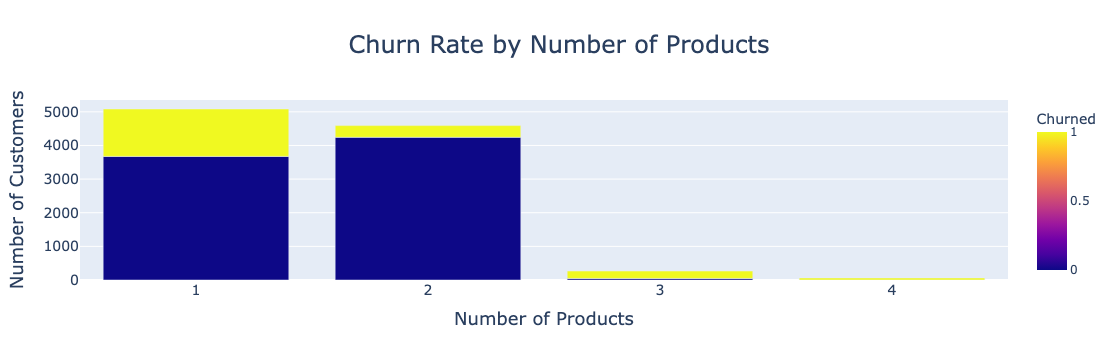

In [606]:
fig = px.bar(
    numprods_churn_counts,
    x='NumProds',
    y='Count',
    color='Churned',
    barmode='group',
    title='Churn Rate by Number of Products',
    labels={'NumProds': 'Number of Products', 'Count': 'Number of Customers'}
)

# Customize the title and axis labels
fig.update_layout(
    title={
        'text': "Churn Rate by Number of Products",
        'y': 0.9,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}  # Adjust the font size of the title
    },
    xaxis_title={
        'text': 'Number of Products',
        'font': {'size': 18}  # Adjust the x-axis title font size
    },
    yaxis_title={
        'text': 'Number of Customers',
        'font': {'size': 18}  # Adjust the y-axis title font size
    }
)

# Adjust the font size of the tick labels
fig.update_xaxes(tickfont={'size': 14})
fig.update_yaxes(tickfont={'size': 14})

fig.show()

In [607]:
print("Percentage of customers churned who have 1 product:")
1409 / (1409 + 3675) * 100

Percentage of customers churned who have 1 product:


27.714398111723053

In [608]:
print("Percentage of customers churned who have 2 products:")
348 / (348 + 4242) * 100

Percentage of customers churned who have 2 products:


7.5816993464052285

In [609]:
print("Percentage of customers churned who have 3 products:")
220 / (220 + 46) * 100

Percentage of customers churned who have 3 products:


82.70676691729322

In [610]:
print("Percentage of customers churned who have 4 products:")
60 / (60 + 0) * 100

Percentage of customers churned who have 4 products:


100.0

- Customers with 3 products have a very high churn rate, at 82\%
- Customers with 4 products have the highest churn rate, at 100\%.

In [612]:
churn.Churned.value_counts()

Churned
0    7963
1    2037
Name: count, dtype: int64

In [613]:
# Filter the DataFrame for customers with Churned == 0 and NumProds == 4
filtered_numProd_customers = churn[(churn['Churned'] == False) & (churn['NumProds'] == 4)]
num_customers = filtered_numProd_customers.shape[0]
print(num_customers)

0


#### There are zero customers, who have 4 products, who have not churned.

### <span style="color:red">Credit Cards</span>

### How many customers, who have credit cards, have Churned ?

In [617]:
# Group by 'Churned' and 'HasCrCard', then count occurrences
HasCrCard_churned_counts = churn.groupby(['Churned', 'HasCrCard']).size().reset_index(name='Count')

# Filter for rows where 'Churned' is True
HasCrCard_churnedTrue_counts = HasCrCard_churned_counts[HasCrCard_churned_counts['Churned'] == True]

print(HasCrCard_churnedTrue_counts)

   Churned  HasCrCard  Count
2        1          0    613
3        1          1   1424


In [618]:
# Extract counts of churned customers with and without credit cards
churned_with_credit_cards = HasCrCard_churnedTrue_counts[HasCrCard_churnedTrue_counts['HasCrCard'] == 1]['Count'].values[0]
total_churned_customers = HasCrCard_churnedTrue_counts['Count'].sum()

# Calculate the proportion and format it as a percentage
cc_churn_proportion = (churned_with_credit_cards / total_churned_customers) * 100

# Print the formatted string
print(f"{cc_churn_proportion:.2f}% of churned customers have credit cards.")

69.91% of churned customers have credit cards.


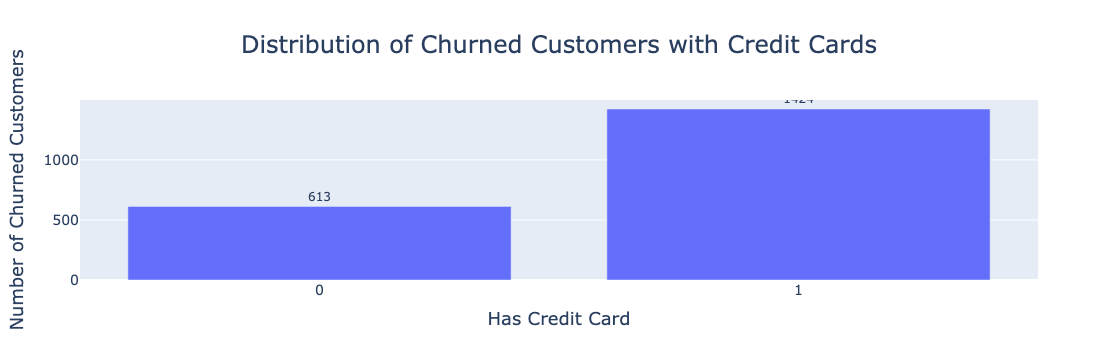

In [619]:
fig = px.bar(
    HasCrCard_churnedTrue_counts,
    x='HasCrCard',
    y='Count',
    title='Distribution of Churned Customers with Credit Cards',
    labels={'HasCrCard': 'Has Credit Card', 'Count': 'Number of Churned Customers'},
    text='Count'
)

# Customize the title and axis labels
fig.update_layout(
    title={
        'text': "Distribution of Churned Customers with Credit Cards",
        'y': 0.9,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}  # Adjust the font size of the title
    },
    xaxis_title={
        'text': 'Has Credit Card',
        'font': {'size': 18}  # Adjust the x-axis title font size
    },
    yaxis_title={
        'text': 'Number of Churned Customers',
        'font': {'size': 18}  # Adjust the y-axis title font size
    }
)

# Adjust the font size of the tick labels
fig.update_xaxes(
    tickfont={'size': 14},
    tickvals=[0, 1],  # Set the tick values to only 0 and 1
    ticktext=['0', '1'],  # Set the tick text to "0" and "1"
    type='category'  # Treat the x-axis as categorical
)

fig.update_yaxes(tickfont={'size': 14})

# Customize the plot to display the counts on the bars
fig.update_traces(texttemplate='%{text}', textposition='outside')

fig.show()

#### There is a much higher percentage of churned customers who have credit cards. The churn rate is 69.9\%.

### <span style="color:red">Is Active</span>

In [622]:
churn['Active'].value_counts()

Active
1    5151
0    4849
Name: count, dtype: int64

In [623]:
# Group by 'Active' and 'Churned', then count occurrences
active_churn_counts = churn.groupby(['Active', 'Churned']).size().reset_index(name='Count')

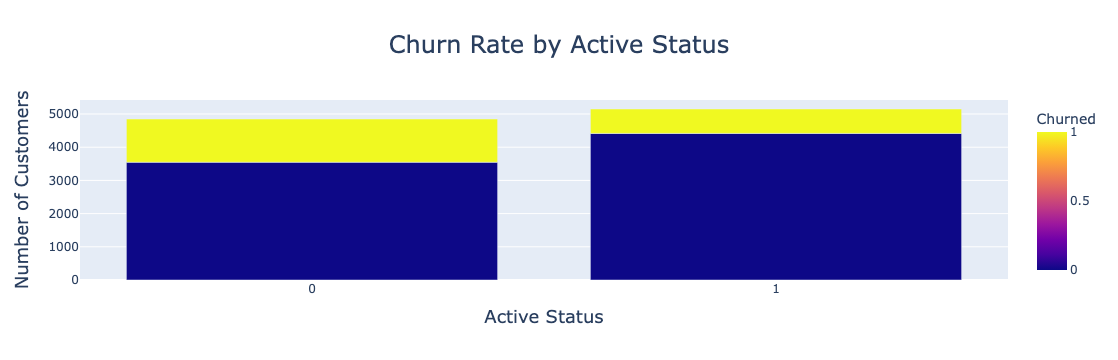

In [624]:
fig = px.bar(
    active_churn_counts,
    x='Active',
    y='Count',
    color='Churned',
    barmode='group',
    title='Churn Rate by Active Status',
    labels={'Active': 'Active Status', 'Count': 'Number of Customers', 'Churned': 'Churned'}
)

# Customize the title and axis labels
fig.update_layout(
    title={
        'text': "Churn Rate by Active Status",
        'y': 0.9,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}  # Adjust the font size of the title
    },
    xaxis_title={
        'text': 'Active Status',
        'font': {'size': 18}  # Adjust the x-axis title font size
    },
    yaxis_title={
        'text': 'Number of Customers',
        'font': {'size': 18}  # Adjust the y-axis title font size
    }
)

fig.show()

#### There are 735 customers who have churned, but are still active.

In [626]:
print(735 / len(churn))

0.0735


#### 7\% of customers have churned, but are still active.

### <span style="color:red">Salary</span>

In [629]:
churn['Salary'].min()

11.58

In [630]:
churn['Salary'].max()

199992.48

In [631]:
# break the 'Salary' column into different levels.
# Define custom bins and labels
bins = [0, 20000, 50000, 90000, 130000, 175000, float('inf')]
labels = ['very poor', 'poor', 'okay', 'good', 'very good', 'excellent']

In [632]:
# Bin the 'Salary' into defined levels and assign labels
churn['SalaryLevel'] = pd.cut(churn['Salary'], bins=bins, labels=labels)

In [633]:
# Display the updated DataFrame
display(churn.head(15))

,Row#,CustID,Name,CredScore,Geo,Gender,Age,Tenure,Balance,NumProds,HasCrCard,Active,Salary,Churned,CredScoreLevel,SalaryLevel
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,good,good
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,good,good
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,okay,good
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,very good,good
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,excellent,okay
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,good,very good
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0,excellent,very poor
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,very poor,good
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,okay,okay
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,very good,okay


In [634]:
# Group by 'CredScoreLevel' and 'Churned', then count occurrences
salaryLevel_churn_counts = churn.groupby(['SalaryLevel', 'Churned'], observed=False).size().reset_index(name='Count')

In [635]:
churn['SalaryLevel'].value_counts()

SalaryLevel
very good    2218
okay         2045
good         2024
poor         1467
excellent    1260
very poor     986
Name: count, dtype: int64

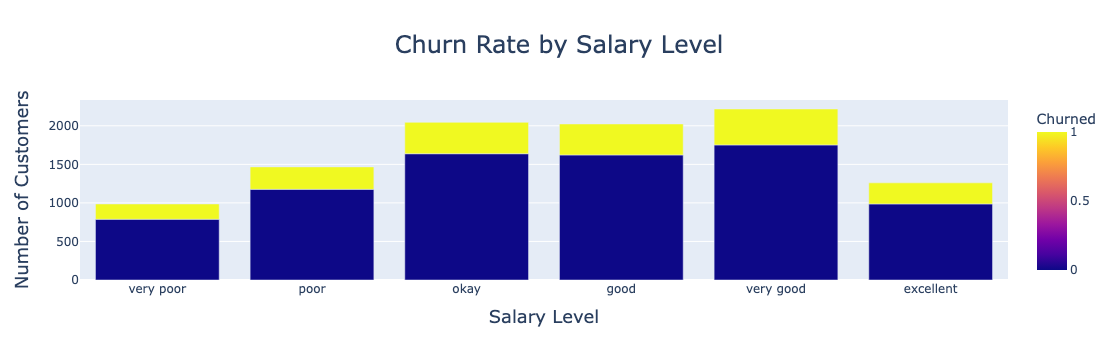

In [636]:
fig = px.bar(
    salaryLevel_churn_counts,
    x='SalaryLevel',
    y='Count',
    color='Churned',
    barmode='group',
    title='Churn Rate by Salary Level',
    labels={'SalaryLevel': 'Salary Level', 'Count': 'Number of Customers', 'Churned': 'Churned'}
)
# Customize the title and axis labels
fig.update_layout(
    title={
        'text': "Churn Rate by Salary Level",
        'y': 0.9,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}  # Adjust the font size of the title
    },
    xaxis_title={
        'text': 'Salary Level',
        'font': {'size': 18}  # Adjust the x-axis title font size
    },
    yaxis_title={
        'text': 'Number of Customers',
        'font': {'size': 18}  # Adjust the y-axis title font size
    }
)
# Show the plot
fig.show()

In [637]:
print("Churn rate for customers with a 'very poor' salary:")
198 / (198 + 788) * 100

Churn rate for customers with a 'very poor' salary:


20.08113590263692

In [638]:
print("Churn rate for customers with a 'poor' salary:")
407 / (407 + 1176) * 100

Churn rate for customers with a 'poor' salary:


25.71067593177511

In [639]:
print("Churn rate for customers with an 'okay' salary:")
291 / (291 + 1638) * 100

Churn rate for customers with an 'okay' salary:


15.085536547433904

In [640]:
print("Churn rate for customers with a 'good' salary:")
402 / (402 + 1622) * 100

Churn rate for customers with a 'good' salary:


19.861660079051383

In [641]:
print("Churn rate for customers with a 'very good' salary:")
466 / (466 + 1752) * 100

Churn rate for customers with a 'very good' salary:


21.009918845807032

In [642]:
print("Churn rate for customers with an 'excellent' salary:")
273 / (273 + 987) * 100

Churn rate for customers with an 'excellent' salary:


21.666666666666668

#### Salary range explanation:
- 'very poor'  ... `$0-$19,999`
- 'poor'       ... `$20,000-$49,999`
- 'okay'       ... `$50,000-$89,999`
- 'good'       ... `$90,000-$130,000`
- 'very good'  ... `$130,000-$175,000`
- 'excellent'  ... `$175,001 and above`

- Churn rate, by salary, ranges from 15\% - 21.6\%.
- The salary group with the lowest churn rate is the 'okay' salary range.

## <div style="color: red; border: 2px solid yellow; display: inline-block;">Supervised Learning</div>

### This next section will use the OHE dataframe.

In [647]:
churn_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row#           10000 non-null  int64  
 1   CustID         10000 non-null  int64  
 2   Name           10000 non-null  object 
 3   CredScore      10000 non-null  int64  
 4   Age            10000 non-null  int64  
 5   Tenure         10000 non-null  int64  
 6   Balance        10000 non-null  float64
 7   Active         10000 non-null  int64  
 8   Salary         10000 non-null  float64
 9   Churned        10000 non-null  int64  
 10  Geo_Germany    10000 non-null  bool   
 11  Geo_Spain      10000 non-null  bool   
 12  Gender_Female  10000 non-null  bool   
 13  Gender_Male    10000 non-null  bool   
 14  NumProds_1     10000 non-null  bool   
 15  NumProds_2     10000 non-null  bool   
 16  NumProds_3     10000 non-null  bool   
 17  NumProds_4     10000 non-null  bool   
 18  HasCrCa

In [648]:
display(churn_ohe.head(15))

,Row#,CustID,Name,CredScore,Age,Tenure,Balance,Active,Salary,Churned,Geo_Germany,Geo_Spain,Gender_Female,Gender_Male,NumProds_1,NumProds_2,NumProds_3,NumProds_4,HasCrCard_0,HasCrCard_1
0,1,15634602,Hargrave,619,42,2,0.00,1,101348.88,1,False,False,True,False,True,False,False,False,False,True
1,2,15647311,Hill,608,41,1,83807.86,1,112542.58,0,False,True,True,False,True,False,False,False,True,False
2,3,15619304,Onio,502,42,8,159660.80,0,113931.57,1,False,False,True,False,False,False,True,False,False,True
3,4,15701354,Boni,699,39,1,0.00,0,93826.63,0,False,False,True,False,False,True,False,False,True,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,79084.10,0,False,True,True,False,True,False,False,False,False,True
5,6,15574012,Chu,645,44,8,113755.78,0,149756.71,1,False,True,False,True,False,True,False,False,False,True
6,7,15592531,Bartlett,822,50,7,0.00,1,10062.80,0,False,False,False,True,False,True,False,False,False,True
7,8,15656148,Obinna,376,29,4,115046.74,0,119346.88,1,True,False,True,False,False,False,False,True,False,True
8,9,15792365,He,501,44,4,142051.07,1,74940.50,0,False,False,False,True,False,True,False,False,True,False
9,10,15592389,H?,684,27,2,134603.88,1,71725.73,0,False,False,False,True,True,False,False,False,False,True


### <span style="color:red">Split the Data</span>

- Dropping the 'Name' column, as this does not add any valuable information for predicting the target.

In [651]:
target = churn_ohe['Churned']
features = churn_ohe.drop(['Churned', 'Name'], axis=1)

<div class="alert alert-block alert-info">
<b>This next cell does a 60/40 split. This includes a validation set:</b> <a class="tocSkip"></a>

In [653]:
features_train, features_remaining, target_train, target_remaining = train_test_split(
    features, target, test_size=0.40, random_state=12345
)

<div class="alert alert-block alert-info">
<b>This next cell takes the remaining 40&#37; and splits it evenly into validation (20&#37;) and test (20&#37;).</b> <a class="tocSkip"></a>
</div>

In [655]:
#includes a validation set...
features_valid, features_test, target_valid, target_test = train_test_split(
    features_remaining, target_remaining, test_size=0.50, random_state=12345
)

<div class="alert alert-block alert-info">
<b>Summary:</b> 
<br>
- Training Set (60%): Used to train the model.
<br>
- Validation Set (20%): Used for hyperparameter tuning.
<br>
- Test Set (20%): Used for final evaluation of the model.  <a class="tocSkip"></a> 
</div>






<div class="alert alert-block alert-info">
<b>When a 3-way(Train, Validation, Test) split is necessary :</b> 
<br>
- Hyperparameter Tuning
<br>
- Avoiding Overfitting<a class="tocSkip"></a> 
</div>

### <span style="color:red">Create the model</span>

- <span style="color:red">Logistic Regression model ... unbalanced:</span>

In [660]:
Logmodel = LogisticRegression(random_state=12345, solver='liblinear')

In [661]:
Logmodel.fit(features_train, target_train)

LogisticRegression(random_state=12345, solver='liblinear')

### Predict and evalute the Logistic Regression unbalanced model:

In [663]:
predicted_valid = Logmodel.predict(features_valid)

In [664]:
accuracy_valid = accuracy_score(target_valid, predicted_valid)

print(accuracy_valid)

0.791


#### 79\% is not great. 

<div class="alert alert-block alert-info">
<br>
- Using F1 score, instead of Accuracy. <a class="tocSkip"></a>

In [667]:
# Calculate the F1 Score for the validation set
print('F1 Score:', f1_score(target_valid, predicted_valid, zero_division=1))

F1 Score: 0.0


#### 0\% is not good. 

<div class="alert alert-block alert-info">
<br>
- The F1 score, which is the harmonic mean of precision and recall, provides a better measure of a model's accuracy on imbalanced datasets than the simple accuracy metric. <a class="tocSkip"></a>

### Sanity Check

In [671]:
target_pred_constant = pd.Series(0, index=target.index)

In [672]:
# Correct the length of target_pred_constant to match target_valid
target_pred_constant = target_pred_constant.loc[target_valid.index]

In [673]:
# Dummy Evaluation metrics
print('Dummy Accuracy:', accuracy_score(target_valid, target_pred_constant))
print('Dummy Precision:', precision_score(target_valid, target_pred_constant, zero_division=1))
print('Dummy Recall:', recall_score(target_valid, target_pred_constant, zero_division=1))
print('Dummy F1 Score:', f1_score(target_valid, target_pred_constant, zero_division=1))

print('\n')
print('Dummy Confusion Matrix:\n', confusion_matrix(target_valid, target_pred_constant))

Dummy Accuracy: 0.791
Dummy Precision: 1.0
Dummy Recall: 0.0
Dummy F1 Score: 0.0


Dummy Confusion Matrix:
 [[1582    0]
 [ 418    0]]


The results indicate that the output of the accuracy_score for the model (0.791) is not better than the accuracy score for a dummy classifier that always predicts the majority class. This implies that the dataset is imbalanced, with one class being significantly more frequent than the other. In this case, accuracy is not a reliable metric for model performance.

- The model did not predict any instances of the minority class. 
- The confusion matrix shows no true positives or false positives for class 1.

### Things to consider when choosing which threshold:

<b>Recall:</b>
- If missing a positive case is very costly (e.g., medical diagnoses, fraud detection), prioritize recall.

<b>Precision: </b>
- If falsely identifying a positive is costly (e.g., spam detection), prioritize precision.

<b>F1 Score: </b>
- If you need a balance between precision and recall, prioritize the F1 score.

<b>Accuracy: </b>
- General cases with balanced datasets where both classes are equally important.


#### Considering this, I think that F1 would be the best to prioritize.

- <span style="color:red">Logistic Regression model ... balanced:</span>

In [679]:
Logmodel2 = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=12345)
Logmodel2.fit(features_train, target_train)
predicted_valid = Logmodel2.predict(features_valid)

In [680]:
probabilities_valid = Logmodel2.predict_proba(features_valid)[:, 1]
print(probabilities_valid)

[0.28292394 0.49271259 0.35009167 ... 0.37921943 0.80892117 0.70649779]


#### Try new thresholds

<div class="alert alert-block alert-info">
<br>
- Trying new thresholds, using a loop. <a class="tocSkip"></a>

In [683]:
# Define a range of thresholds to evaluate
thresholds = np.arange(0.1, 0.9, 0.1)

In [684]:
for threshold in thresholds:
    predicted_valid_threshold = (probabilities_valid >= threshold).astype(int)
    
    # ANSI escape sequences for blue text and reset
    BLUE = '\033[94m'
    RESET = '\033[0m'

    print(f'{BLUE}Threshold: {threshold}{RESET}')
    print('\n')
    
    print('Accuracy:', accuracy_score(target_valid, predicted_valid_threshold))
    print('Precision:', precision_score(target_valid, predicted_valid_threshold, zero_division=1))
    print('Recall:', recall_score(target_valid, predicted_valid_threshold, zero_division=1))
    print('F1 Score:', f1_score(target_valid, predicted_valid_threshold, zero_division=1))
    
    print('\n')
    print('Confusion Matrix:\n', confusion_matrix(target_valid, predicted_valid_threshold))
    print('\n')
    print('\n')

Threshold: 0.1


Accuracy: 0.212
Precision: 0.20962888665997995
Recall: 1.0
F1 Score: 0.3466003316749585


Confusion Matrix:
 [[   6 1576]
 [   0  418]]




Threshold: 0.2


Accuracy: 0.274
Precision: 0.22293676312968919
Recall: 0.9952153110047847
F1 Score: 0.36427320490367776


Confusion Matrix:
 [[ 132 1450]
 [   2  416]]




Threshold: 0.30000000000000004


Accuracy: 0.4235
Precision: 0.25774555042847724
Recall: 0.9354066985645934
F1 Score: 0.4041343669250646


Confusion Matrix:
 [[ 456 1126]
 [  27  391]]




Threshold: 0.4


Accuracy: 0.5875
Precision: 0.3138151875571821
Recall: 0.8205741626794258
F1 Score: 0.45400397088021177


Confusion Matrix:
 [[832 750]
 [ 75 343]]




Threshold: 0.5


Accuracy: 0.7135
Precision: 0.3936899862825789
Recall: 0.6866028708133971
F1 Score: 0.5004359197907585


Confusion Matrix:
 [[1140  442]
 [ 131  287]]




Threshold: 0.6


Accuracy: 0.778
Precision: 0.4693396226415094
Recall: 0.47607655502392343
F1 Score: 0.47268408551068886


Confusion Matrix:

<div class="alert alert-block alert-info">
<br>
- Scroll to see the results. <a class="tocSkip"></a>

### As threshold goes up, False Negatives go up (Confusion Matrix: low left corner.)

#### I don't think that Logistic Regression is the best model to use to make predictions for this dataset. I cannot get a good F1 score. I have tried different thresholds.

- <span style="color:red">Decision Tree model ... unbalanced</span>

In [689]:
Treemodel = DecisionTreeClassifier(random_state=12345)

In [690]:
Treemodel.fit(features_train, target_train)

DecisionTreeClassifier(random_state=12345)

In [691]:
predicted_valid = Treemodel.predict(features_valid)

In [692]:
f1 = f1_score(target_valid, predicted_valid, zero_division=1)
print(f'F1 Score: {f1}')

F1 Score: 0.5108958837772397


#### F1 score is too low.

In [694]:
print(confusion_matrix(target_valid, predicted_valid))

[[1385  197]
 [ 207  211]]


### Explanation of Confusion Matrix:

- TN in the upper-left corner
- TP in the lower right corner

- FP in the upper right corner
- FN in the lower-left corner

#### TP, in lower right corner of the confusion matrix, at 211, is very low.

### Balance the data

- <span style="color:red">Inspect the Target ('Churned' column)</span>

In [699]:
class_counts = churn_ohe['Churned'].value_counts()
class_proportions = class_counts / len(churn_ohe)
print(class_proportions)

Churned
0    0.7963
1    0.2037
Name: count, dtype: float64


#### It is imbalanced. 80\% remained as customers. 20\% have churned.

- <span style="color:red">Decision Tree model ... balanced</span>

#### Try different tree depths

In [703]:
for depth in range(1, 7):
    Treemodel2 = DecisionTreeClassifier(random_state=12345, max_depth=depth)
    Treemodel2.fit(features_train, target_train)
    predictions_valid = Treemodel2.predict(features_valid)
    
    print('max_depth =', depth, ': ', end='')
    print(accuracy_score(target_valid, predictions_valid))
    
    precision = precision_score(target_valid, predictions_valid, zero_division=1)
    recall = recall_score(target_valid, predictions_valid, zero_division=1)
    f1 = f1_score(target_valid, predictions_valid, zero_division=1)
    conf_matrix = confusion_matrix(target_valid, predictions_valid)


max_depth = 1 : 0.791
max_depth = 2 : 0.821
max_depth = 3 : 0.848
max_depth = 4 : 0.8555
max_depth = 5 : 0.856
max_depth = 6 : 0.854


In [704]:
    print("Precision:")
    print(precision)
    print('\n')
    
    print("Recall:")
    print(recall)
    print('\n')
    
    print("F1:")
    print(f1)
    print('\n')
    
    print("Confusion matrix:")
    print(conf_matrix)

Precision:
0.7889908256880734


Recall:
0.41148325358851673


F1:
0.5408805031446541


Confusion matrix:
[[1536   46]
 [ 246  172]]


#### F1 is still low.

- <span style="color:red">Random Forest model ... unbalanced</span>

In [707]:
best_score = 0
best_est = 0

In [708]:
for est in range(1, 11):
    RFmodel = RandomForestClassifier(random_state=54321, n_estimators=est)
    RFmodel.fit(features_train, target_train)
    
    predictions_valid = RFmodel.predict(features_valid)
    
    f1 = f1_score(target_valid, predictions_valid, zero_division=1)
    
    if f1 > best_score:
        best_score = f1
        best_est = est

In [709]:
print(f'Best F1 Score on Validation Set: {best_score}')
print(f'Best n_estimators: {best_est}')

Best F1 Score on Validation Set: 0.5608011444921316
Best n_estimators: 7


- <span style="color:red">Random Forest model ... balanced</span>

In [711]:
# Combine the feature and target training sets into a single DataFrame
train_data = pd.concat([features_train, target_train], axis=1)

In [712]:
# Separate the majority and minority classes
majority_class = train_data[train_data['Churned'] == 0]
minority_class = train_data[train_data['Churned'] == 1]

In [713]:
# Downsample majority class
majority_downsampled = resample(majority_class,
                                replace=False,    
                                n_samples=len(minority_class),
                                random_state=123)

In [714]:
# Combine minority class with downsampled majority class
downsampled_train_data = pd.concat([majority_downsampled, minority_class])

### balance the data using downsampling

In [716]:
# Separate features and target
features_resampled = downsampled_train_data.drop('Churned', axis=1)
target_resampled = downsampled_train_data['Churned']

In [717]:
# Check balanced class distribution
print("Class distribution after downsampling:")
print(target_resampled.value_counts())

Class distribution after downsampling:
Churned
0    1196
1    1196
Name: count, dtype: int64


#### Data looks balanced now.

### <span style="color:red">Final model</span>

### Build a new Random Forest model.

### Find best params

In [722]:
print(best_est)

7


In [723]:
# Hyperparameter tuning with nested loops
best_score = 0
best_params = {'n_estimators': 0, 'max_depth': 0}

In [724]:
# Range of values to try for n_estimators and max_depth
n_estimators_range = [7, 10, 50, 100, 200]
max_depth_range = [None, 8, 10, 20, 30]

In [725]:
# Range of values to try for n_estimators and max_depth
n_estimators_range = [10, 50, 100, 200]
max_depth_range = [None, 10, 20, 30]

for n_estimators in n_estimators_range:
    for max_depth in max_depth_range:
        rf = RandomForestClassifier(random_state=54321, n_estimators=n_estimators, max_depth=max_depth)
        rf.fit(features_resampled, target_resampled)
        
        # Evaluate on the validation set
        predictions_valid = rf.predict(features_valid)
        f1 = f1_score(target_valid, predictions_valid, zero_division=1)
        
        if f1 > best_score:
            best_score = f1
            best_params['n_estimators'] = n_estimators
            best_params['max_depth'] = max_depth

In [726]:
print(f'Best F1 Score: {best_score}')
print(f'Best Parameters: {best_params}')

Best F1 Score: 0.5949953660797034
Best Parameters: {'n_estimators': 200, 'max_depth': 10}


<div class="alert alert-block alert-info">
<br>
- Adding in the FINAL MODEL (below) <a class="tocSkip"></a>

### Train the FINAL MODEL, using best params

In [729]:
print("BEST params: ", best_params)

BEST params:  {'n_estimators': 200, 'max_depth': 10}


In [730]:
# Train the final Random Forest model with the best params
final_rf_model = RandomForestClassifier(random_state=54321, 
                                        n_estimators=best_params['n_estimators'], 
                                        max_depth=best_params['max_depth'])

In [731]:
final_rf_model.fit(features_resampled, target_resampled)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=54321)

In [732]:
# Predict probabilities on the validation set
probabilities_valid = final_rf_model.predict_proba(features_valid)[:, 1]

In [733]:
# Default threshold (0.5)
predicted_valid_default = (probabilities_valid >= 0.5).astype(int)

In [734]:
print("Accuracy:", accuracy_score(target_valid, predicted_valid_default))

Accuracy: 0.7815


In [735]:
print("F1 Score:", f1_score(target_valid, predicted_valid_default, zero_division=1))

F1 Score: 0.5949953660797034


#### F1 score is now acceptable

- <span style="color:red">Find AUC-ROC:</span>

In [738]:
# Calculate the AUC-ROC score
auc_roc = roc_auc_score(target_valid, probabilities_valid)

print('AUC-ROC Score:', auc_roc)

AUC-ROC Score: 0.8486229652973947


#### AUC ROC of .848 is very good.

### Explanation of Auc-Roc score:
- 0.5 indicates a model that makes random predictions.
- 1.0 indicates a perfect model.
- Greater than 0.8 is often considered indicative of a strong model.
- Greater than 0.9 is excellent.

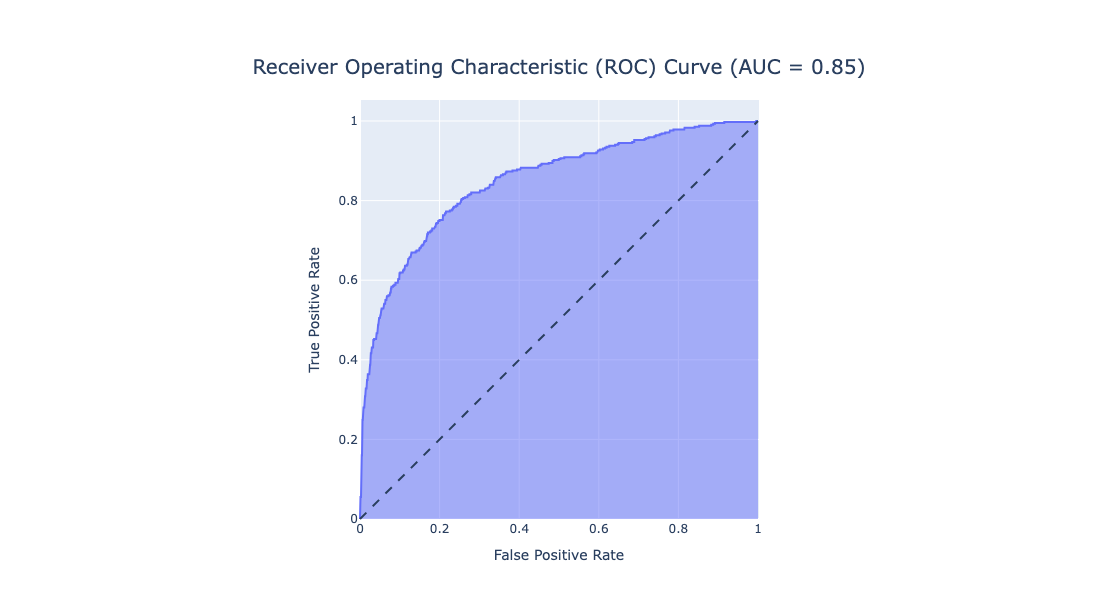

In [741]:
# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_valid)
fig = px.area(
    x=fpr, y=tpr,
    title=f'Receiver Operating Characteristic (ROC) Curve (AUC = {auc_roc:.2f})',
    labels=dict(x='False Positive Rate', y='True Positive Rate'),
    width=800, height=600
)

fig.add_shape(
    type='line',
    line=dict(dash='dash'),
    x0=0, x1=1, y0=0, y1=1
)

fig.update_layout(
    title={
        'text': f'Receiver Operating Characteristic (ROC) Curve (AUC = {auc_roc:.2f})',
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 20}  # Adjust the size as needed
    }
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_xaxes(constrain='domain')
fig.show()

## <div style="color: red; border: 2px solid yellow; display: inline-block;">Conclusion:</div>

## Exploring the Data:

<b>Credit Score</b>
- The highest churn rate is for customers with 'very poor' credit (349-424), at 47.1\% churn rate.
- The lowest churn rate is for customers with 'very good' credit (650-724), at 18.5\% churn rate.

<b>Geography</b>
- There are 3 regions in this dataset: France, Germany, Spain.
- Most customers are from France.
- The highest churn rate is from Germany, at 48\%.

<b>Gender</b>
- Most customers are male. The churn rate, for males, is 16.45\%.
- Most customers who churn are female, at 25\%

<b>Age</b>
- The minimum age of customers is 18. The maximum is 92.
- The lowest churn rate comes from the 23-48 age group, with the very lowest churn rate being ages 35-37 years old.

<b>Tenure</b>
- Customers tenure goes from 0-11 years.
- Most customers have a tenure of 5 years.
- Customers who have a tenure of 1 year, or less, have the highest churn rate.
- Customers who have a tenure of 7 years have the lowest churn rate.

<b>Bank Balance</b>
- Bank balances range from \$0 - 250,898.
- The average bank balance is \$76,485.
- The median churn rate, based on balance, is \$109,349.

<b>Number of Products</b>
- Most customers have only 1 product.
- The lowest churn rate is for customers with 2 products.
- The churn rate for customers with 3 products is 82\%.
- The highest churn rate is for customers with 4 products, at 100\%.

<b>Has Credit Card</b>
- 69.91\% of customers who have churned have a credit card.

<b>Is Active</b>
- 7\% of customers who have churned are still active.

<b>Salary</b>
- Salaries range from \$12 - 200,000.
- The majority of customers have a very good salary, in the range of \$130,000 - 175,000.
- The lowest churn rate is for customers with an "okay" salary of \$50,000 - 89,000.
- The highest churn rate is for customers with a "poor" salary of \$ 20,000 - 49,000.

<b>Supervised Learning</b>
- The best model was the Random Forest model, using data that was downsampled to balance the data.
- f1 was .60
- Accuracy was 78\%.

<b>AUC ROC</b>
- The AUC ROC scored 84.8\% which is very good.